# Procesamiento de datos

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from transformers import AutoTokenizer, Trainer, AutoModelForSequenceClassification, TrainingArguments, AutoModelForCausalLM, pipeline
import numpy as np
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
from gensim.models import Word2Vec, KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize, word_tokenize
from transformers import BertTokenizer, BertModel, AutoTokenizer, AutoModel
import torch.nn.functional as F
import torch
import nltk
import numpy as np
from gensim.models.callbacks import CallbackAny2Vec
from sklearn.preprocessing import LabelEncoder

/home/david/code/class_projects/fallacy-classification/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Descargar datasets y combinarlos

In [2]:

# Diccionario para mapear tipos de falacia del segundo dataset a las clases del primero
fallacy_mapping = {
    # ad hominem
    "Ad Hominem": "ad hominem",
    "Circumstantial Ad Hominem": "ad hominem",
    "Tu Quoque": "ad hominem",
    "Abusive Ad Hominem": "ad hominem",
    "Guilt By Association": "ad hominem",
    "Argument From Commitment": "ad hominem",
    "Precedent Ad Hominem": "ad hominem",
    "Behavioral Ad Hominem": "ad hominem",
    "Ad Hominem Against a Witness at Trial": "ad hominem",

    # false dilemma
    "False Dichotomy": "false dilemma",
    "False Dilemma/Dichotomy": "false dilemma",
    "False dilemma": "false dilemma",

    # ad populum
    "Appeal to Popularity": "ad populum",
    "Bandwagon Fallacy": "ad populum",
    "Common Belief Fallacy": "ad populum",

    # equivocation
    "Equivocation": "equivocation",

    # fallacy of credibility
    "Argument from Authority": "fallacy of credibility",
    "Appeal to Authority": "fallacy of credibility",
    "Appeal to False Authority": "fallacy of credibility",
    "Argument from False Authority": "fallacy of credibility",
    "Appealing to an irrelevant authority": "fallacy of credibility",

    # false causality
    "Correlation does not imply causation": "false causality",
    "False cause": "false causality",
    "Post hoc ergo propter hoc": "false causality",
    "Cum hoc ergo propter hoc": "false causality",

    # intentional
    "Intentional Fallacy": "intentional",
    "Authorial Intent as Constraint": "intentional",

    # fallacy of logic / circular reasoning
    "Circular Reasoning": "circular reasoning",
    "Circular reasoning": "circular reasoning",
    "Fallacy of Logic": "fallacy of logic",
    "Begging the question": "fallacy of logic",
    "Begging the Question": "fallacy of logic",

    # appeal to emotion
    "Appeal to Emotion": "appeal to emotion",
    "Appeal to emotion": "appeal to emotion",
    "Appeal to Pity": "appeal to emotion",
    "Appeal to fear": "appeal to emotion",
    "Appeal to consequences": "appeal to emotion",

    # fallacy of relevance / extension
    "Fallacy of Extension": "fallacy of extension",
    "Fallacy of Relevance": "fallacy of relevance",
    "Red Herring": "fallacy of relevance",
    "Straw Man": "fallacy of relevance",
    "Straw man": "fallacy of relevance",
    "Strawman": "fallacy of relevance",

    # faulty generalization
    "Hasty Generalization": "faulty generalization",
    "Faulty Generalization ": "faulty generalization",
    "Hasty generalization": "faulty generalization",
    "Accident": "faulty generalization",
    "Generalization": "faulty generalization",
}

# Cargar datasets
dataset1 = load_dataset("tasksource/logical-fallacy")
dataset2 = load_dataset("MrOvkill/fallacies-fallacy-base")

train1, test1, dev1 = dataset1["train"], dataset1["test"], dataset1["dev"]

# Mapear clases del dataset2 a las del dataset1
def map_fallacy(example):
    mapped = fallacy_mapping.get(example["name"])
    return {"logical_fallacies": mapped}

dataset2_mapped = dataset2["train"].map(map_fallacy)
dataset2_mapped = dataset2_mapped.filter(lambda x: x["logical_fallacies"] is not None)

# Mantener solo columnas necesarias
dataset2_mapped = dataset2_mapped.remove_columns(
    [c for c in dataset2_mapped.column_names if c not in ["logical_fallacies", "example"]]
)

# Dividir dataset2 en train/dev/test (80/10/10)
data_array = dataset2_mapped["example"]
labels_array = dataset2_mapped["logical_fallacies"]

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    data_array, labels_array, test_size=0.2, stratify=labels_array, random_state=42
)
dev_texts, test_texts, dev_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

train2 = Dataset.from_dict({"example": train_texts, "logical_fallacies": train_labels})
dev2   = Dataset.from_dict({"example": dev_texts, "logical_fallacies": dev_labels})
test2  = Dataset.from_dict({"example": test_texts, "logical_fallacies": test_labels})

train2 = train2.rename_column("example", "source_article")
dev2   = dev2.rename_column("example", "source_article")
test2  = test2.rename_column("example", "source_article")

# Combinar datasets
train_combined = concatenate_datasets([train1, train2])
dev_combined   = concatenate_datasets([dev1, dev2])
test_combined  = concatenate_datasets([test1, test2])

all_labels = list(train_combined["logical_fallacies"]) + \
             list(dev_combined["logical_fallacies"]) + \
             list(test_combined["logical_fallacies"])

le = LabelEncoder()
le.fit(all_labels)

fallacy_names = le.classes_.tolist()

train_combined = train_combined.map(lambda x: {"logical_fallacies": int(le.transform([x["logical_fallacies"]])[0])})
dev_combined   = dev_combined.map(lambda x: {"logical_fallacies": int(le.transform([x["logical_fallacies"]])[0])})
test_combined  = test_combined.map(lambda x: {"logical_fallacies": int(le.transform([x["logical_fallacies"]])[0])})

dataset = DatasetDict({
    "train": train_combined,
    "dev": dev_combined,
    "test": test_combined
})

train = dataset["train"]
dev   = dataset["dev"]
test  = dataset["test"]

print(dataset)
print(f"Train examples: {len(dataset['train'])}")
print(f"Dev examples:   {len(dataset['dev'])}")
print(f"Test examples:  {len(dataset['test'])}")


DatasetDict({
    train: Dataset({
        features: ['config', 'source_article', 'logical_fallacies'],
        num_rows: 2901
    })
    dev: Dataset({
        features: ['config', 'source_article', 'logical_fallacies'],
        num_rows: 598
    })
    test: Dataset({
        features: ['config', 'source_article', 'logical_fallacies'],
        num_rows: 539
    })
})
Train examples: 2901
Dev examples:   598
Test examples:  539


# Tokenizer

Hay que usar el tokenizer respectivo del modelo a entrenar

In [9]:

# model_ckpt = "distilbert-base-uncased"
model_ckpt = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize(batch):
    return tokenizer(
        batch["source_article"],
        padding=True,
        truncation=True,
        max_length=384 # 256
    )


### Tokenizar dataset con el tokenizer de RoBERTa

In [10]:

# Renombrar la columna de las labels a label
encoded_dataset = dataset.rename_column("logical_fallacies", "label")

# Tokenizar dataset
encoded_dataset = encoded_dataset.map(tokenize, batched=True)

# Quitar columna de texto plano (Una vez tokenizado ya no hace falta)
encoded_dataset = encoded_dataset.remove_columns(["source_article"])

# Convertir a formato compatible con torch
encoded_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print(f"Text: {dataset['train'][0]['source_article']}")
print(f"Label: {encoded_dataset['train'][0]['label']}")
print(f"Tokens: {encoded_dataset['train'][0]['input_ids']}")
print(f"Attention mask: {encoded_dataset['train'][0]['attention_mask']}")


Text: company's slogan "Expect More. Pay Less."
Label: 2
Tokens: tensor([    0, 24233,    18, 16760,    22,  9089, 13771,   901,     4,  6898,
        10862,    72,     2,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,

# Modelo transformer para clasificacion

In [11]:

num_labels = len(set(dataset["train"]["logical_fallacies"]))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=num_labels
).to(device)


Using device: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Metricas de evaluacion

In [4]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    precision = precision_score(labels, preds, average="weighted", zero_division=0)
    recall = recall_score(labels, preds, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }



### Entrenamiento

In [ ]:
from transformers import TrainingArguments, Trainer

batch_size = 16
logging_steps = len(encoded_dataset["train"]) // batch_size

training_args = TrainingArguments(
    output_dir="./models/roberta",
    num_train_epochs=8,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=logging_steps,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    label_smoothing_factor=0.1 # El label smoothing ayuda con el desbalance de clases
)

# El modelo se evalua con el dev set durante entrenamiento y con el test set despues de entrenamiento
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["dev"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

test_results = trainer.evaluate(encoded_dataset["test"])
print(test_results)


/tmp/ipykernel_21228/855021150.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,2.324700,1.972661,0.438127,0.407481,0.503293,0.438127
2,1.753600,1.789393,0.494983,0.493394,0.547397,0.494983
3,1.400900,1.789170,0.521739,0.516521,0.537145,0.521739
4,1.182400,1.735739,0.541806,0.546849,0.572571,0.541806
5,1.013700,1.825788,0.525084,0.526960,0.547071,0.525084
6,0.918100,1.904486,0.521739,0.520377,0.536014,0.521739
7,0.841000,1.887831,0.521739,0.523130,0.535769,0.521739
8,0.794400,1.926306,0.520067,0.522647,0.536165,0.520067


{'eval_loss': 1.8927581310272217, 'eval_accuracy': 0.4842300556586271, 'eval_f1': 0.48454218104414726, 'eval_precision': 0.5051044923864433, 'eval_recall': 0.4842300556586271, 'eval_runtime': 1.7519, 'eval_samples_per_second': 307.664, 'eval_steps_per_second': 19.407, 'epoch': 8.0}


# Desbalance de clases

Class distribution (train set):
Class 0: 314
Class 1: 217
Class 2: 259
Class 3: 152
Class 4: 67
Class 5: 215
Class 6: 139
Class 7: 188
Class 8: 205
Class 9: 228
Class 10: 161
Class 11: 423
Class 12: 333


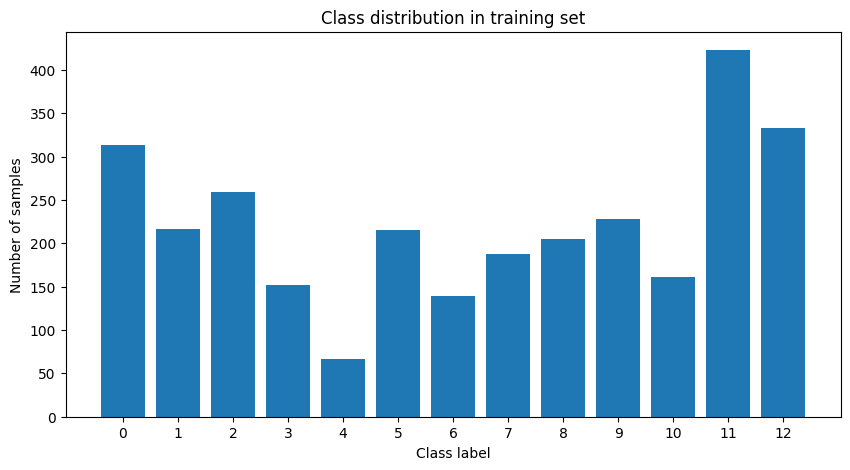

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Extraer labels
labels = dataset["train"]["logical_fallacies"]

# Contar las veces que aparece cada tipo de falacia en el dataset
label_counts = Counter(labels)

print("Class distribution (train set):")
for label, count in sorted(label_counts.items()):
    print(f"Class {label}: {count}")

# Plot
plt.figure(figsize=(10, 5))
plt.bar(label_counts.keys(), label_counts.values())
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class distribution in training set")
plt.xticks(sorted(label_counts.keys()))
plt.show()


In [ ]:

num_labels = len(set(dataset["train"]["logical_fallacies"]))

label_counts = Counter(dataset["train"]["logical_fallacies"])

weights = np.zeros(num_labels)

# Ponderar las labels con su frecuencia de aparicion inversa
for label, count in label_counts.items():
    weights[label] = 1.0 / count

weights = weights / weights.sum() * num_labels

class_weights = torch.tensor(weights, dtype=torch.float)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"Class {i}: {w:.4f}")


Class weights:
Class 0: 0.5818
Class 1: 0.8418
Class 2: 0.7053
Class 3: 1.2018
Class 4: 2.7265
Class 5: 0.8496
Class 6: 1.3142
Class 7: 0.9717
Class 8: 0.8911
Class 9: 0.8012
Class 10: 1.1346
Class 11: 0.4319
Class 12: 0.5486


In [ ]:

# El WeightedTrainer utiliza CrossEntropyLoss con clases ponderadas con los pesos computados previamente
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.model.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [17]:

training_args = TrainingArguments(
    output_dir="./models/roberta-weighted",
    num_train_epochs=10,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=logging_steps,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["dev"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

trainer.train()

test_results = trainer.evaluate(encoded_dataset["test"])
print(test_results)


/tmp/ipykernel_21228/3969842907.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.773500,1.746141,0.500000,0.502381,0.522881,0.500000
2,0.504700,1.920075,0.491639,0.495008,0.522298,0.491639
3,0.323200,2.209992,0.478261,0.480780,0.517167,0.478261
4,0.247500,2.106096,0.518395,0.522776,0.543707,0.518395
5,0.283200,2.103353,0.494983,0.501135,0.526962,0.494983
6,0.249200,2.271925,0.494983,0.495587,0.518484,0.494983
7,0.211100,2.216926,0.510033,0.513377,0.526866,0.510033
8,0.175300,2.290113,0.515050,0.518921,0.535345,0.515050
9,0.152700,2.449646,0.508361,0.510727,0.528754,0.508361
10,0.129500,2.411869,0.510033,0.514043,0.530891,0.510033


{'eval_loss': 2.4235894680023193, 'eval_accuracy': 0.46567717996289426, 'eval_f1': 0.46123923893013924, 'eval_precision': 0.47469113950939096, 'eval_recall': 0.46567717996289426, 'eval_runtime': 1.6748, 'eval_samples_per_second': 321.829, 'eval_steps_per_second': 20.301, 'epoch': 10.0}


# RoBERTa Large

In [5]:

# model_ckpt = "microsoft/deberta-v3-base"
model_ckpt = "roberta-large"

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize(batch):
    return tokenizer(
        batch["source_article"],
        padding=True,
        truncation=True,
        max_length=384 # 256
    )

encoded_dataset = dataset.rename_column("logical_fallacies", "label")
encoded_dataset = encoded_dataset.map(tokenize, batched=True)
encoded_dataset = encoded_dataset.remove_columns(["source_article"])
encoded_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

num_labels = len(set(dataset["train"]["logical_fallacies"]))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=num_labels
).to(device)

batch_size = 16
logging_steps = len(encoded_dataset["train"]) // batch_size

training_args = TrainingArguments(
    output_dir="./models/deberta",
    num_train_epochs=10,
    learning_rate=1e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=logging_steps,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    label_smoothing_factor=0.1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["dev"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

test_results = trainer.evaluate(encoded_dataset["test"])
print(test_results)


Using device: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_36867/104335556.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,2.425200,2.098422,0.377926,0.341739,0.526004,0.377926
2,1.831400,1.766958,0.493311,0.494900,0.561191,0.493311
3,1.446700,1.692863,0.538462,0.538448,0.566642,0.538462
4,1.204800,1.650358,0.580268,0.584866,0.617068,0.580268
5,1.028900,1.697042,0.563545,0.563699,0.592052,0.563545
6,0.916600,1.788679,0.556856,0.558042,0.583349,0.556856
7,0.838700,1.789154,0.578595,0.580237,0.595710,0.578595
8,0.783100,1.802684,0.565217,0.566393,0.574240,0.565217
9,0.741100,1.805752,0.571906,0.572450,0.584707,0.571906
10,0.714000,1.807915,0.575251,0.576824,0.587231,0.575251


{'eval_loss': 1.7434598207473755, 'eval_accuracy': 0.5454545454545454, 'eval_f1': 0.5478106029048594, 'eval_precision': 0.58399604583718, 'eval_recall': 0.5454545454545454, 'eval_runtime': 5.4597, 'eval_samples_per_second': 98.723, 'eval_steps_per_second': 6.227, 'epoch': 10.0}


# Explicacion de falacias con LLM

In [ ]:

# Prompt con 3 ejemplos de inputs/outputs (Phew-shot)
FEW_SHOT_PROMPT = """
You are an expert in logical reasoning and informal fallacies.
Your task is to explain clearly and concisely why an argument is fallacious.

Example 1:
Argument: "You shouldn't listen to his opinion on climate change because he didn't finish college."
Fallacy: Ad Hominem
Explanation: This is an ad hominem fallacy because the argument attacks the person instead of addressing the validity of the claim about climate change.

Example 2:
Argument: "If we allow students to redo exams, academic standards will completely collapse."
Fallacy: Slippery Slope
Explanation: This is a slippery slope fallacy because it assumes a single action will inevitably lead to extreme consequences without sufficient evidence.

Example 3:
Argument: "Everyone I know supports this policy, so it must be the right decision."
Fallacy: Bandwagon
Explanation: This is a bandwagon fallacy because it treats popularity as evidence of correctness.

Now analyze the following argument:

Argument: "{argument}"
Fallacy: "{label}"
Explanation:
"""

model_ckpt = "microsoft/Phi-3-mini-4k-instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_ckpt,
    device_map="cuda",
    dtype="auto"
)

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=200,
    do_sample=False,      # Determinista (mayor consistencia)
)


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.71it/s]
Device set to use cuda
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [7]:

argument = "If we ban violent movies, crime will disappear."
label = "False Cause"

prompt = FEW_SHOT_PROMPT.format(argument=argument, label=label)

output = generator(prompt)
print(output[0]["generated_text"])




The argument presented is fallacious because it commits a false cause fallacy, also known as post hoc ergo propter hoc (after this, therefore because of this). This fallacy occurs when it is assumed that because one event follows another, the first event must be the cause of the second. In this case, the argument suggests that banning violent movies will lead to the disappearance of crime. However, this is a causal fallacy because it assumes a direct cause-and-effect relationship between the two without sufficient evidence to support such a claim.

Crime is a complex social issue with multiple contributing factors, including but not limited to poverty, education, mental health, and social inequality. While it is possible that exposure to violent media may influence some individuals' behavior, it is overly simplistic and unsupported to claim that banning violent movies alone will lead to the disappearance of crime.




In [ ]:

def explain_fallacy(argument, label):
    prompt = FEW_SHOT_PROMPT.format(argument=argument, label=label)
    output = generator(prompt)
    return output[0]["generated_text"]

results = []

subset = dataset["test"][:20]

# Generar respuestas para varios pares de argumento/falacia
for argument, label_id in zip(subset["source_article"], subset["logical_fallacies"]):

    explanation = explain_fallacy(
        argument,
        fallacy_names[label_id]
    )

    results.append({
        "argument": argument,
        "label": fallacy_names[label_id],
        "explanation": explanation
    })

results

[{'argument': 'People who drive big cars probably hate the environment.',
  'label': 'fallacy of extension',
  'explanation': '\n\nThe fallacy in the argument is not the "fallacy of extension." The correct fallacy is the "hasty generalization" fallacy. This fallacy occurs when a conclusion is drawn about a whole group based on an inadequate sample size. In this case, the argument assumes that all people who drive big cars hate the environment, which is a hasty generalization. It\'s possible that some people who drive big cars are environmentally conscious or have other reasons for choosing a large vehicle.\n\n\n'},
 {'argument': "White men can't jump. No, really, they can't!",
  'label': 'faulty generalization',
  'explanation': "\nThis argument is fallacious because it commits a faulty generalization. A faulty generalization occurs when a conclusion is drawn about an entire group based on insufficient or non-representative evidence. In this case, the argument makes a sweeping statemen